In [1]:
import torch
from transformers import CLIPProcessor, CLIPModel
from transformers import AutoProcessor, AutoModel
from PIL import Image
import matplotlib.pyplot as plt
import shapiq 
import src
import open_clip

import src
import src.game_huggingface
import src.game_openclip

import os

In [ ]:
from datasets import load_dataset
from huggingface_hub import login

login(token=os.getenv("HF_TOKEN"))  

ds = load_dataset("redlessone/Derm1M")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [3]:
ds["train"][0]

{'filename': 'IIYI/26549_2.png',
 'caption': 'Male, 15 years old, has been experiencing spontaneous blistering all over his body since childhood, which heals and forms flat scars as shown in the attached image. The self-assumed diagnosis is dystrophic epidermolysis bullosa, based on a 10-year-old photo with no other available information. Other users and specialists in the forum agree with the diagnosis of dystrophic epidermolysis bullosa, although only photographic evidence was used to support this conclusion.',
 'truncated_caption': 'Male, 15 years old, has been experiencing spontaneous blistering all over his body since childhood, which heals and forms flat scars as shown in the attached image. The self-assumed diagnosis is dystrophic epidermolysis bullosa, based on a 10-year-old photo with no other available information. Other users and specialists in the forum agree with the diagnosis of dystrophic epidermolysis bullosa, although only photographic evidence was used to support this

In [4]:
# LOAD DERMLIP
model_dermlip, _, preprocess_dermlip = open_clip.create_model_and_transforms('hf-hub:redlessone/DermLIP_ViT-B-16')
model_dermlip.eval()

image = preprocess_dermlip(Image.open("derm_train_images/pubmed/0d_59_PMC4458964_IJD_60_321e_g003_0.png")).unsqueeze(0)
# Initialize tokenizer
tokenizer_dermlip = open_clip.get_tokenizer('hf-hub:redlessone/DermLIP_ViT-B-16')

# Read example image

# Define disease labels (example: PAD dataset classes)
PAD_CLASSNAMES = [
    "nevus",
    "basal cell carcinoma",
    "actinic keratosis",
    "seborrheic keratosis",
    "squamous cell carcinoma",
    "melanoma"
]

# Build text prompts
template = lambda c: f'This is a skin image of {c}'
text = tokenizer_dermlip([template(c) for c in PAD_CLASSNAMES])

# Inference
with torch.no_grad(), torch.autocast("cuda"):
    # Encode image and text
    image_features = model_dermlip.encode_image(image)
    text_features = model_dermlip.encode_text(text)
    
    # Normalize features
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)
    
    # Compute similarity
    text_probs = (100.0 * image_features @ text_features.T).softmax(dim=-1)

# Get prediction
final_prediction = PAD_CLASSNAMES[torch.argmax(text_probs[0])]
print(f'This image is diagnosed as {final_prediction}.')
print("Label probabilities:", text_probs)

This image is diagnosed as nevus.
Label probabilities: tensor([[0.4391, 0.0087, 0.0382, 0.2123, 0.0077, 0.2939]])


In [3]:
pubmed_filenames = [
    "98_6c_PMC5383004_pone.0172624.g006_3.jpg",
    "00_39_PMC10381143_jimaging-09-00148-g011_1.jpg",
    "0d_59_PMC4458964_IJD_60_321e_g003_0.png",
    "e2_67_PMC3445843_1471_5945_12_7_7.png",
    "89_38_PMC3350198_CRIM.PEDIATRICS2012_152602.002_1.png"
]

IIYI_filenames = [
    "2281_1.png",
    "14083_1.png",
]

youtube_filenames = [
    "OzBKmWt9zWo_frame_8071_0_0.jpg"
]

download_tasks = {
    "pubmed": pubmed_filenames,
    "IIYI": IIYI_filenames,
    "youtube": youtube_filenames
}

# Fetch all filenames from the training split
all_filenames = ds["train"]["filename"]

data = []

print("Searching for images in the dataset...\n")

for category, filenames in download_tasks.items():
    for target in filenames:
        found = False
        
        # In the dataset, filenames usually look like: "pubmed/00_39_PMC..." 
        # or "IIYI/2281_1.png" depending on the zip they come from.
        search_target = f"{category}/{target}"
        
        # Iterate through all filenames to find a substring match
        for idx, ds_filename in enumerate(all_filenames):
            if ds_filename and search_target in ds_filename:
                
                # Format to match your local structure: derm_train_images/{category}/{filename}
                data.append({
                    "filename": f"derm_train_images/{category}/{target}", 
                    "index": idx
                })
                
                found = True
                break  # Move to the next target once found
                
        if not found:
            print(f"[!] Not found: {search_target}")

import json
print("data =", json.dumps(data, indent=4))

Searching for images in the dataset...

data = [
    {
        "filename": "derm_train_images/pubmed/98_6c_PMC5383004_pone.0172624.g006_3.jpg",
        "index": 329100
    },
    {
        "filename": "derm_train_images/pubmed/00_39_PMC10381143_jimaging-09-00148-g011_1.jpg",
        "index": 151106
    },
    {
        "filename": "derm_train_images/pubmed/0d_59_PMC4458964_IJD_60_321e_g003_0.png",
        "index": 132556
    },
    {
        "filename": "derm_train_images/pubmed/e2_67_PMC3445843_1471_5945_12_7_7.png",
        "index": 397502
    },
    {
        "filename": "derm_train_images/pubmed/89_38_PMC3350198_CRIM.PEDIATRICS2012_152602.002_1.png",
        "index": 279559
    },
    {
        "filename": "derm_train_images/IIYI/2281_1.png",
        "index": 126
    },
    {
        "filename": "derm_train_images/IIYI/14083_1.png",
        "index": 228492
    },
    {
        "filename": "derm_train_images/youtube/OzBKmWt9zWo_frame_8071_0_0.jpg",
        "index": 321
    }
]


In [11]:
print(ds["train"][data[0]["index"]])

{'filename': 'pubmed/98_6c_PMC5383004_pone.0172624.g006_3.jpg', 'caption': 'Another volunteer from Group 2 shown before the treatment, demonstrating baseline global facial wrinkles. Arrows point out specific areas of interest.', 'truncated_caption': 'Another volunteer from Group 2 shown before the treatment, demonstrating baseline global facial wrinkles. Arrows point out specific areas of interest.', 'source': 'pubmed_fail', 'source_type': 'knowledge', 'disease_label': 'no definitive diagnosis', 'hierarchical_disease_label': None, 'skin_concept': 'No visual concepts', 'body_location': 'face', 'symptoms': 'No symptom information', 'age': 'No age information', 'gender': 'No gender information'}



[hf-hub:redlessone/DermLIP_ViT-B-16] Loading Model...

  -> Processing sample 329100: derm_train_images/pubmed/98_6c_PMC5383004_pone.0172624.g006_3.jpg
     [ Initializing OpenCLIP Game ] Patch Size=16
     [ Game Initialized ] TextPlayers=24, ImagePlayers=196
Interaction values:  InteractionValues(
    index=FWBII, max_order=2, min_order=0, estimated=True, estimation_budget=1024,
    n_players=220, baseline_value=0.00450537519307441,
    Top 10 interactions:
        (213,): 0.11324984564755745
        (199, 211): 0.11324984564755694
        (199, 213): 0.11324984564755694
        (211, 213): 0.11324984564755694
        (211,): 0.11324984564755429
        (132, 207): 0.10946129894411265
        (199, 200): -0.10874447045448621
        (200, 206): -0.10874447045448621
        (200, 207): -0.10874447045448621
        (200,): -0.10874447045448654
)
     [ Generating Explainer Plot ]


/home/zzox/xai/xai_project/dermlip/src/utils.py:175: UserWarning: Index `FWBII` is not a valid interaction index. Valid indices are: SII, BII, CHII, Co-Moebius, SGV, BGV, CHGV, IGV, EGV, k-SII, STII, FSII, kADD-SHAP, FBII, SV, BV, JointSV, Moebius, ELC.
  return shapiq.InteractionValues(
/home/zzox/miniforge3/envs/dermlip/lib/python3.12/site-packages/shapiq/interaction_values.py:707: UserWarning: Index `FWBII` is not a valid interaction index. Valid indices are: SII, BII, CHII, Co-Moebius, SGV, BGV, CHGV, IGV, EGV, k-SII, STII, FSII, kADD-SHAP, FBII, SV, BV, JointSV, Moebius, ELC.
  return InteractionValues(


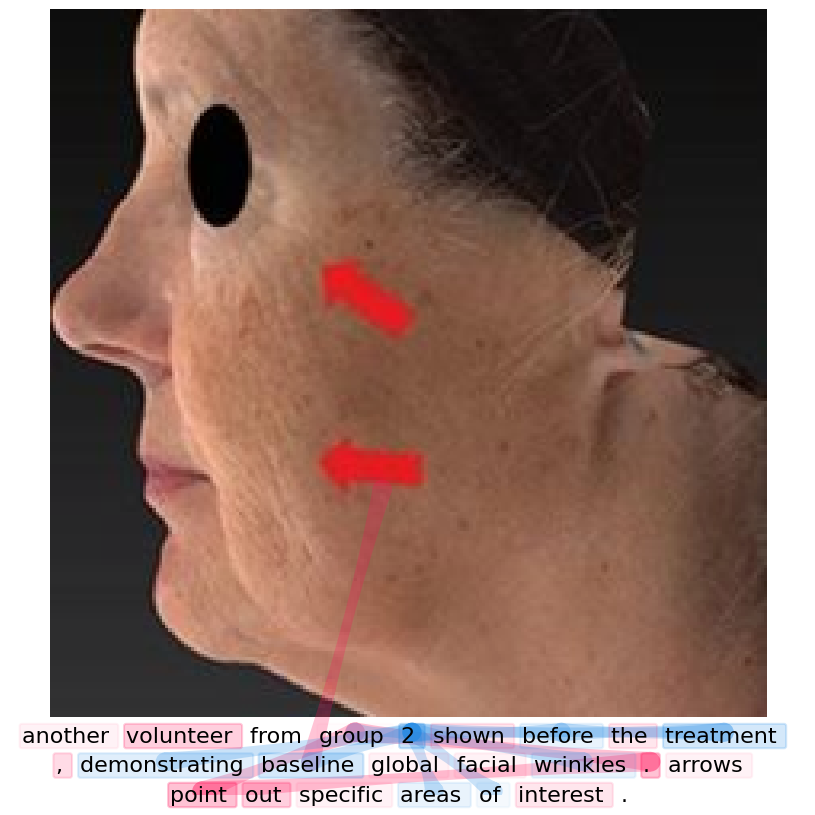


  -> Processing sample 151106: derm_train_images/pubmed/00_39_PMC10381143_jimaging-09-00148-g011_1.jpg
     [ Initializing OpenCLIP Game ] Patch Size=16
     [ Game Initialized ] TextPlayers=19, ImagePlayers=196
Interaction values:  InteractionValues(
    index=FWBII, max_order=2, min_order=0, estimated=True, estimation_budget=1024,
    n_players=215, baseline_value=0.00027353379557535154,
    Top 10 interactions:
        (118, 201): -0.09380510391133519
        (133, 201): -0.09471889583721117
        (133, 204): -0.09471889583721117
        (133, 209): -0.09471889583721117
        (119, 200): -0.09912460879904447
        (119, 205): -0.09912460879904447
        (133, 200): -0.10101228530532538
        (133, 205): -0.10101228530532538
        (118, 200): -0.1115733040418026
        (118, 205): -0.1115733040418026
)
     [ Generating Explainer Plot ]


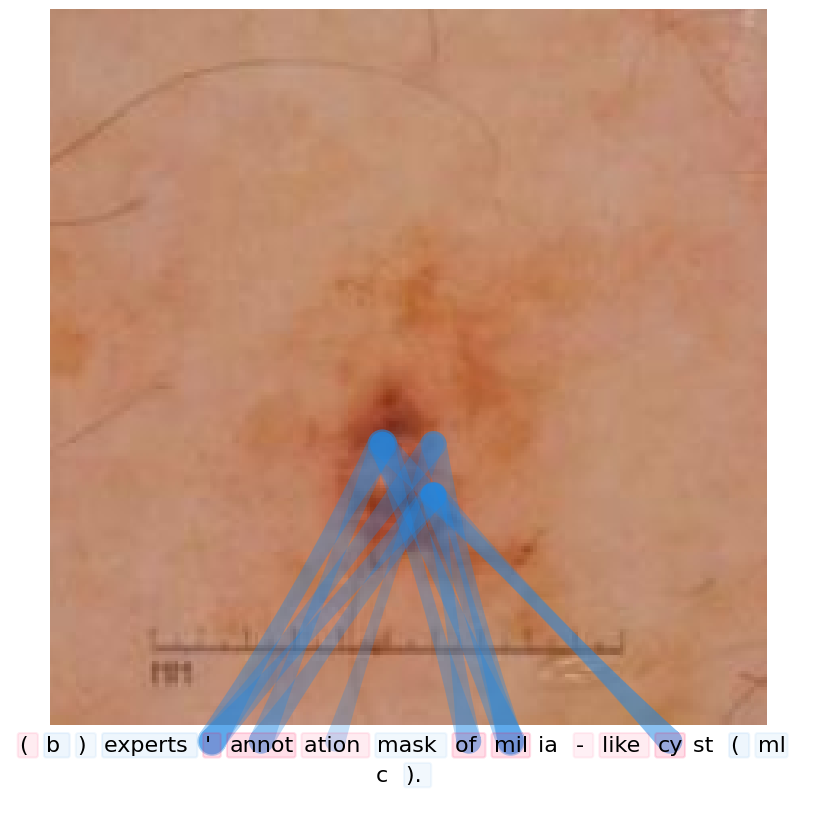


  -> Processing sample 132556: derm_train_images/pubmed/0d_59_PMC4458964_IJD_60_321e_g003_0.png
     [ Initializing OpenCLIP Game ] Patch Size=16
     [ Game Initialized ] TextPlayers=10, ImagePlayers=196
Interaction values:  InteractionValues(
    index=FWBII, max_order=2, min_order=0, estimated=True, estimation_budget=1024,
    n_players=206, baseline_value=0.003167418749911546,
    Top 10 interactions:
        (61, 201): 0.17697651002691878
        (61, 197): 0.17484830221599987
        (62, 201): 0.14827030523283408
        (62, 204): -0.1565938255206582
        (61, 200): -0.1822634809204253
        (61, 204): -0.1843916887313441
        (196, 201): -0.20594973377501521
        (199, 201): -0.20594973377501521
        (201, 205): -0.20594973377501521
        (201,): -0.20594973377501652
)
     [ Generating Explainer Plot ]


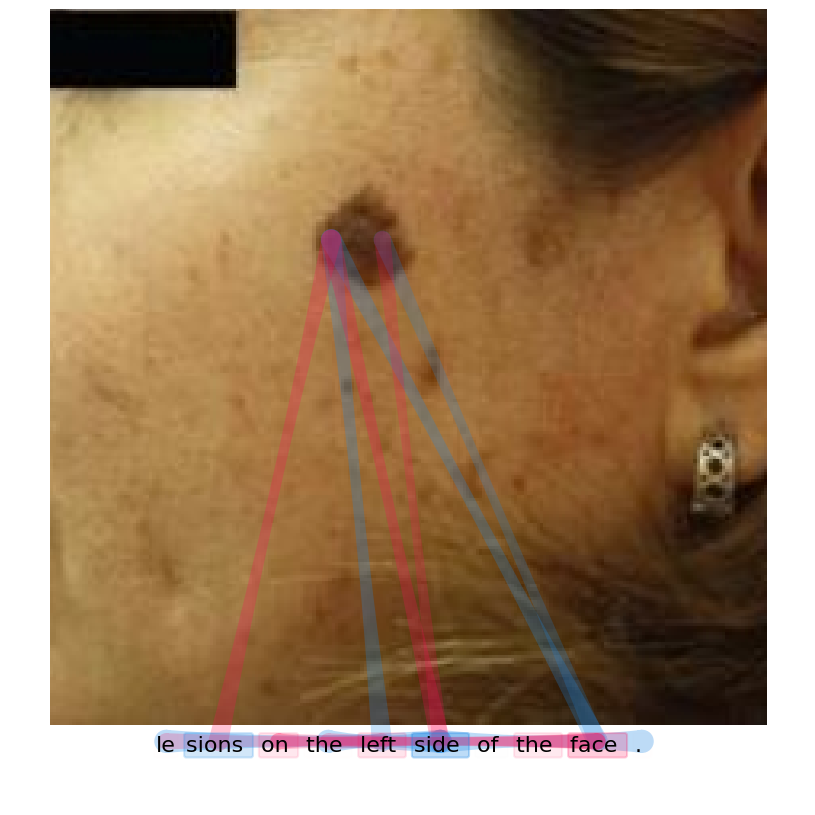


  -> Processing sample 397502: derm_train_images/pubmed/e2_67_PMC3445843_1471_5945_12_7_7.png
     [ Initializing OpenCLIP Game ] Patch Size=16
     [ Game Initialized ] TextPlayers=8, ImagePlayers=196
Interaction values:  InteractionValues(
    index=FWBII, max_order=2, min_order=0, estimated=True, estimation_budget=1024,
    n_players=204, baseline_value=-0.007523162592530056,
    Top 10 interactions:
        (200,): 0.2722536103726147
        (200, 202): 0.2722536103726143
        (201, 202): 0.2722536103726143
        (196, 197): -0.27977677296516823
        (196, 199): -0.27977677296516823
        (196, 203): -0.27977677296516823
        (197, 203): -0.27977677296516823
        (203,): -0.4879128325444804
        (199, 203): -0.4879128325444977
        (202, 203): -0.4879128325444977
)
     [ Generating Explainer Plot ]


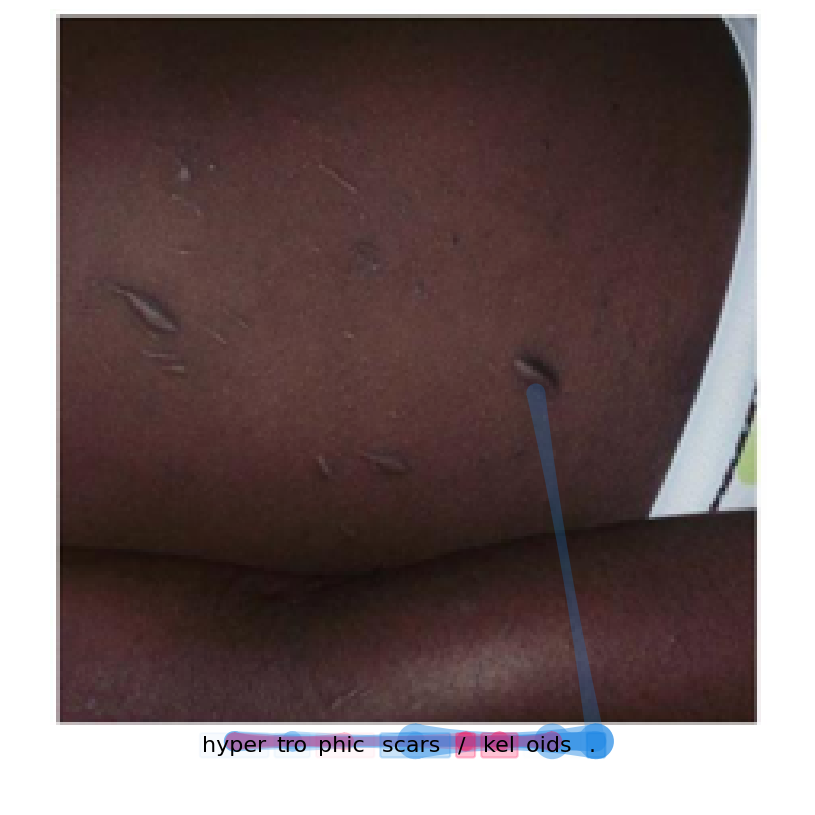


  -> Processing sample 279559: derm_train_images/pubmed/89_38_PMC3350198_CRIM.PEDIATRICS2012_152602.002_1.png
     [ Initializing OpenCLIP Game ] Patch Size=16
     [ Game Initialized ] TextPlayers=7, ImagePlayers=196


In [ ]:
import src.utils
import src.plot
import matplotlib.pyplot as plt


# Testing DermLIP models on Derm1M dataset samples

models_to_test = [
    {"name": "hf-hub:redlessone/DermLIP_ViT-B-16", "backend": "open_clip"},
]

results = {}

for model_info in models_to_test:
    model_name = model_info["name"]
    backend = model_info["backend"]
    print(f"\n{'='*60}\n[{model_name}] Loading Model...\n{'='*60}")

    # ==========================================
    # 1. Load Model dynamically based on backend
    # ==========================================
    if backend == "huggingface":
        model = AutoModel.from_pretrained(model_name).to('cuda').eval()
        processor = AutoProcessor.from_pretrained(model_name)
        tokenizer = processor # HF uses combined processors
        image_mean = processor.image_processor.image_mean
        image_std = processor.image_processor.image_std
    else: # open_clip
        model, _, processor = open_clip.create_model_and_transforms(model_name)
        model = model.to('cuda').eval()
        tokenizer = open_clip.get_tokenizer(model_name)
        
        image_mean = (0.48145466, 0.4578275, 0.40821073)
        image_std = (0.26862954, 0.26130258, 0.27577711)
        
        patch_size = 16
        if hasattr(model.visual, 'patch_size'):
            if isinstance(model.visual.patch_size, tuple):
                patch_size = model.visual.patch_size[0]
            else:
                patch_size = model.visual.patch_size

    results[model_name] = []

    # ==========================================
    # 2. Iterate over samples
    # ==========================================
    for item in data:
        img_path = item["filename"]
        idx = item["index"]
        print(f"\n  -> Processing sample {idx}: {img_path}")
        sample = ds["train"][idx]
        input_text = sample["caption"]
                
        try:
            input_image = Image.open(img_path).convert("RGB")
        except FileNotFoundError:
            print(f"     [!] Image not found at {img_path}. Skipping.")
            continue

        # ==========================================
        # 3. Create the Game
        # ==========================================
        if backend == "huggingface":
            game = src.game_huggingface.VisionLanguageGame(
                model=model,
                processor=processor,
                input_image=input_image,
                input_text=input_text,
                batch_size=32 
            )
        else: # open_clip
            print(f"     [ Initializing OpenCLIP Game ] Patch Size={patch_size}")
            game = src.game_openclip.OpenCLIPGame(
                model=model,
                image_processor=processor,
                text_tokenizer=tokenizer,
                input_image=input_image,
                input_text=input_text,
                patch_size=patch_size,
                batch_size=32 
            )
            
        if (game.n_players_text > 30):
            print(f"     [!] Too many text players ({game.n_players_text}). Skipping sample.")
            continue

        print(f"     [ Game Initialized ] TextPlayers={game.n_players_text}, ImagePlayers={game.n_players_image}")

        # ==========================================
        # 4. Compute Explanations via FIxLIP 
        # ==========================================
        approximator = src.fixlip.FIxLIP(
            n_players_text=game.n_players_text,
            n_players_image=game.n_players_image,
            max_order=2,
            p=0.5, # weight
            random_state=42
        )
        
        interaction_values = approximator.approximate_crossmodal(
            game=game,
            budget=2**10
        )
        
        print("Interaction values: ", interaction_values)
        
        results[model_name].append({
            "idx": idx,
            "filename": sample["filename"],
            "interaction_values": interaction_values
        })
        
        # ==========================================
        # 5. Extract Details & Visualize
        # ==========================================
        # Extract Text Tokens (strip boundaries based on n_players_text)
        if backend == "huggingface":
            # Extract tokens via the tokenizer directly with the input_ids
            input_ids = game.inputs["input_ids"][0]
            if hasattr(tokenizer, "convert_ids_to_tokens"):
                text_tokens = tokenizer.convert_ids_to_tokens(input_ids)
            else:
                text_tokens = [tokenizer.decode([t.item()]) for t in input_ids]
        else:
            if hasattr(tokenizer, "decode"):
                token_ids = tokenizer(input_text)[0]
                text_tokens = [tokenizer.decode([t.item()]) for t in token_ids]
            else:
                text_tokens = tokenizer(input_text)[0].numpy().tolist()
                text_tokens = [str(t) for t in text_tokens]

        if len(text_tokens) > game.n_players_text:
            text_tokens = text_tokens[1:game.n_players_text+1]
        
        text_tokens = [tok.replace('</w>', '').replace('<|startoftext|>', '').replace('<|endoftext|>', '') for tok in text_tokens]
        
        if backend == "huggingface":
            input_image_processed = game.inputs['pixel_values'].squeeze(0)
        else:
            input_image_processed = game.inputs[0].squeeze(0)
        input_image_denormalized = src.utils.denormalize(
            input_image_processed, 
            image_mean, 
            image_std
        ).permute(1, 2, 0).numpy()
        
        # Plot Heatmap & Word importances
        print(f"     [ Generating Explainer Plot ]")
        src.plot.plot_image_and_text_together(
            img=input_image_denormalized,
            text=text_tokens,
            image_players=list(range(game.n_players_image)),
            iv=interaction_values,
            plot_interactions=True,
            top_k=13,
            normalize_jointly=True,
            figsize=(8, 8),
            fontsize=16,
            margin=0.3,
            color_text=True,
            plot_heatmap=True,
            show=True,
            max_value=float(interaction_values.values.max() * 4)
        )
        plt.tight_layout(pad=0.15)
        plt.show()

        plt.close('all')
        
        # 2. Delete heavy variables 
        del game
        del approximator
        del interaction_values
        del input_image
        del input_image_processed
        del input_image_denormalized
        del text_tokens
            
        # 3. Force Garbage Collection and clear GPU memory cache
        import gc
        gc.collect()
        torch.cuda.empty_cache()

print(f"\n[{model_name}] Finished!\n")

# Free memory
del model
del processor
if backend == "open_clip":
    del tokenizer
torch.cuda.empty_cache()


[hf-hub:redlessone/DermLIP_ViT-B-16] Loading Model...
     [Model Loaded] Image Mean=(0.48145466, 0.4578275, 0.40821073), Image Std=(0.26862954, 0.26130258, 0.27577711), Patch Size=16

**************************************************
-> Processing Image 0: ham_images/sample_2_melanoma.jpg
**************************************************

--- Model Output for ham_images/sample_2_melanoma.jpg ---
  melanocytic nevus        : Logit = 22.6094, Prob = 0.0349
  melanoma                 : Logit = 25.7656, Prob = 0.8184
  basal cell carcinoma     : Logit = 20.6250, Prob = 0.0048
  benign keratosis         : Logit = 22.9688, Prob = 0.0499
  actinic keratosis        : Logit = 20.6406, Prob = 0.0049
  vascular lesion          : Logit = 21.7344, Prob = 0.0145
  dermatofibroma           : Logit = 23.3438, Prob = 0.0726
-----------------------------------

   ==> Generating Explanation for Class: 'melanocytic nevus'


/home/zzox/xai/xai_project/dermlip/src/utils.py:175: UserWarning: Index `FWBII` is not a valid interaction index. Valid indices are: SII, BII, CHII, Co-Moebius, SGV, BGV, CHGV, IGV, EGV, k-SII, STII, FSII, kADD-SHAP, FBII, SV, BV, JointSV, Moebius, ELC.
  return shapiq.InteractionValues(
/home/zzox/miniforge3/envs/dermlip/lib/python3.12/site-packages/shapiq/interaction_values.py:707: UserWarning: Index `FWBII` is not a valid interaction index. Valid indices are: SII, BII, CHII, Co-Moebius, SGV, BGV, CHGV, IGV, EGV, k-SII, STII, FSII, kADD-SHAP, FBII, SV, BV, JointSV, Moebius, ELC.
  return InteractionValues(


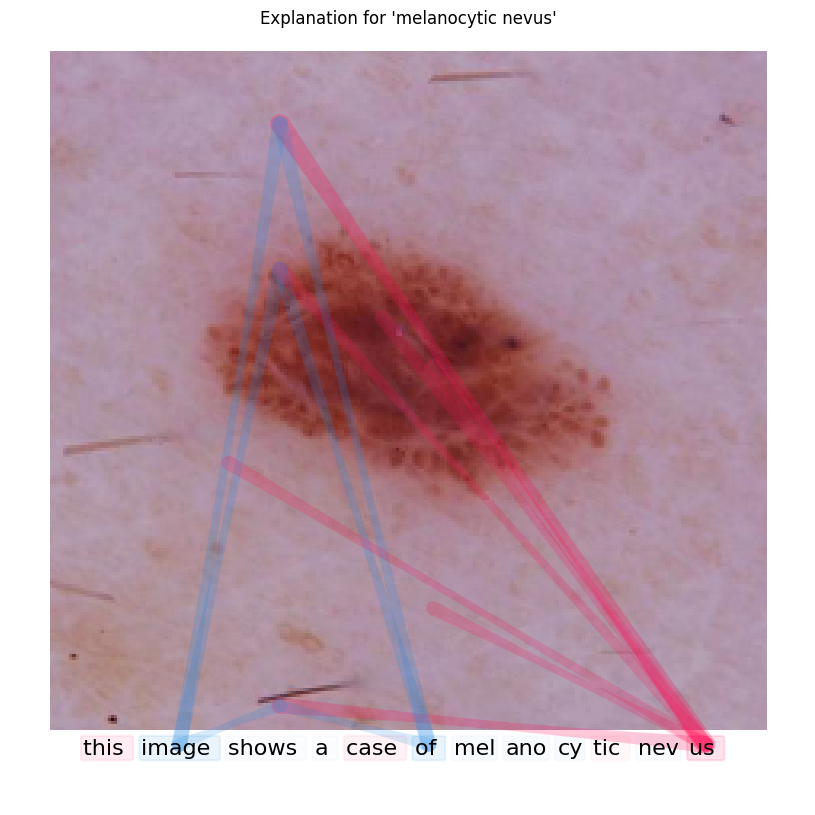


   ==> Generating Explanation for Class: 'melanoma'


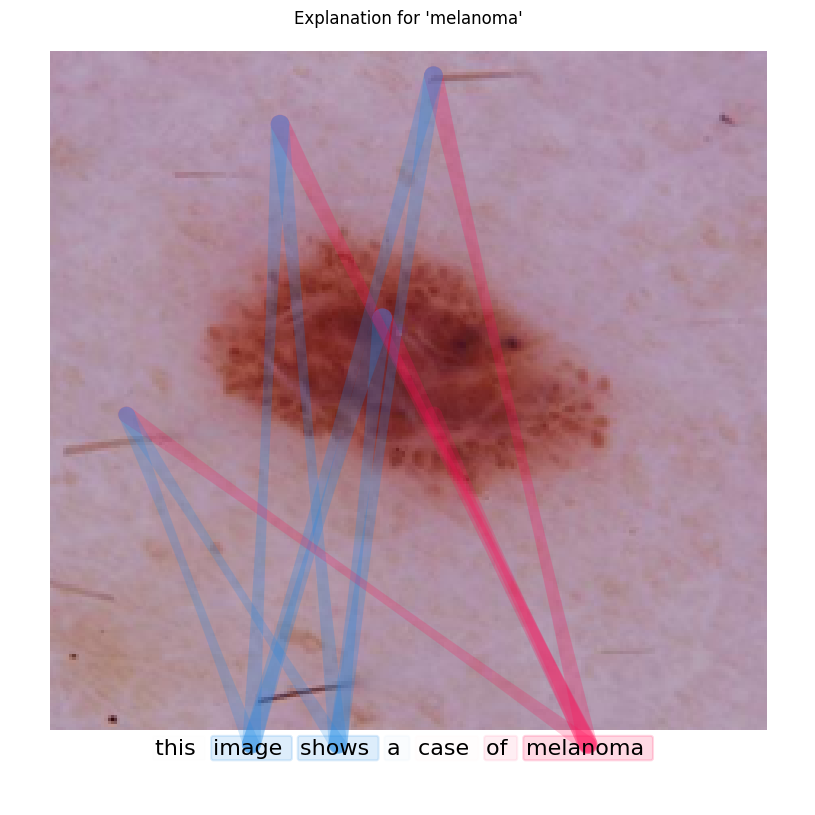


   ==> Generating Explanation for Class: 'basal cell carcinoma'


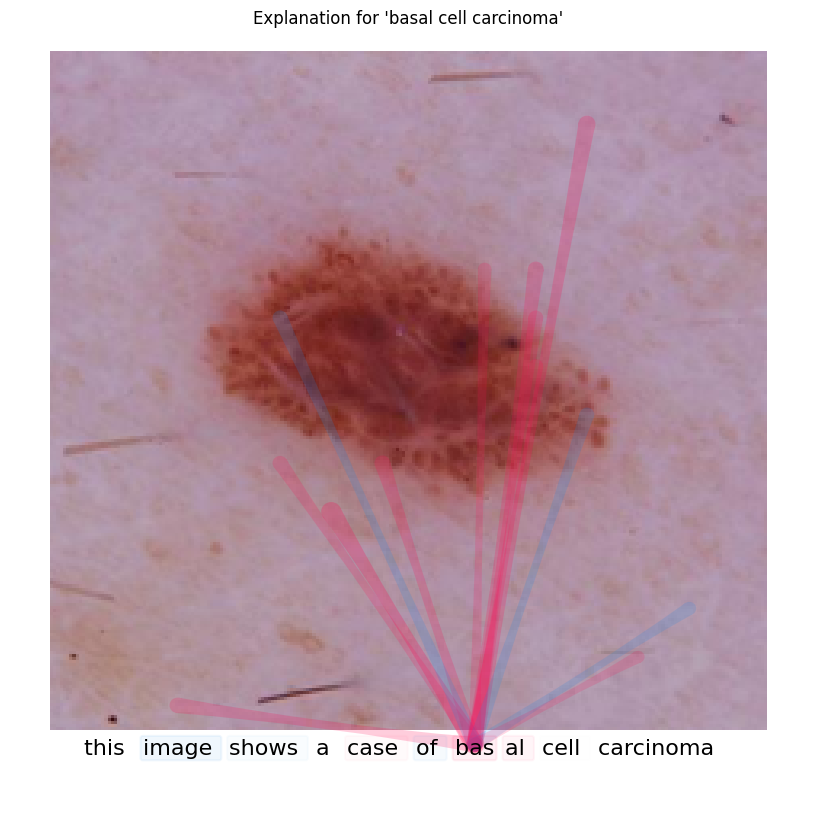


   ==> Generating Explanation for Class: 'benign keratosis'


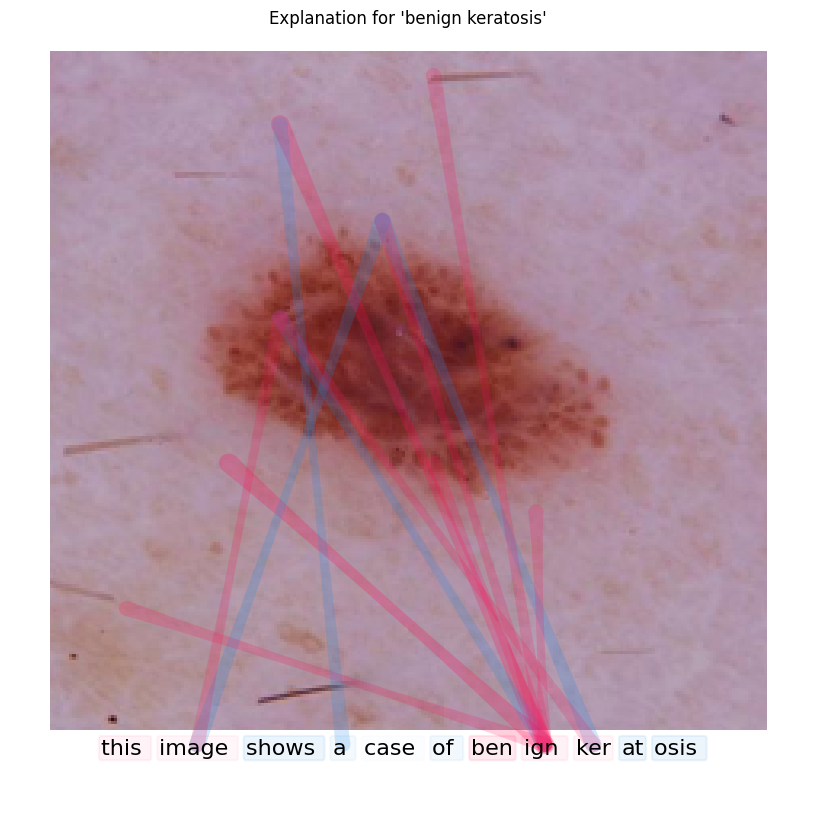


   ==> Generating Explanation for Class: 'actinic keratosis'


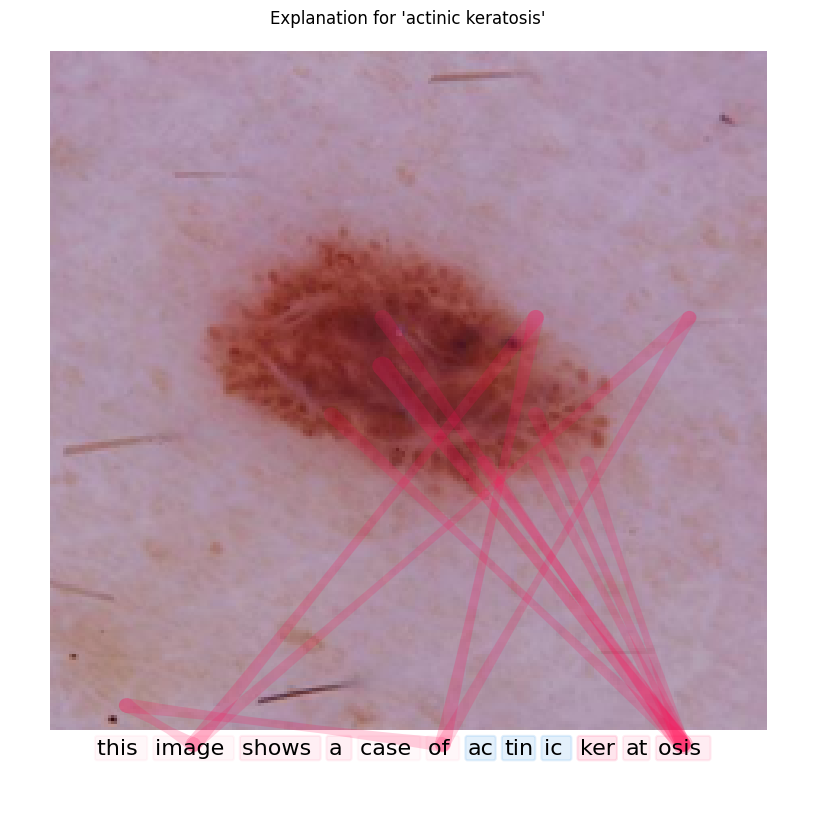


   ==> Generating Explanation for Class: 'vascular lesion'


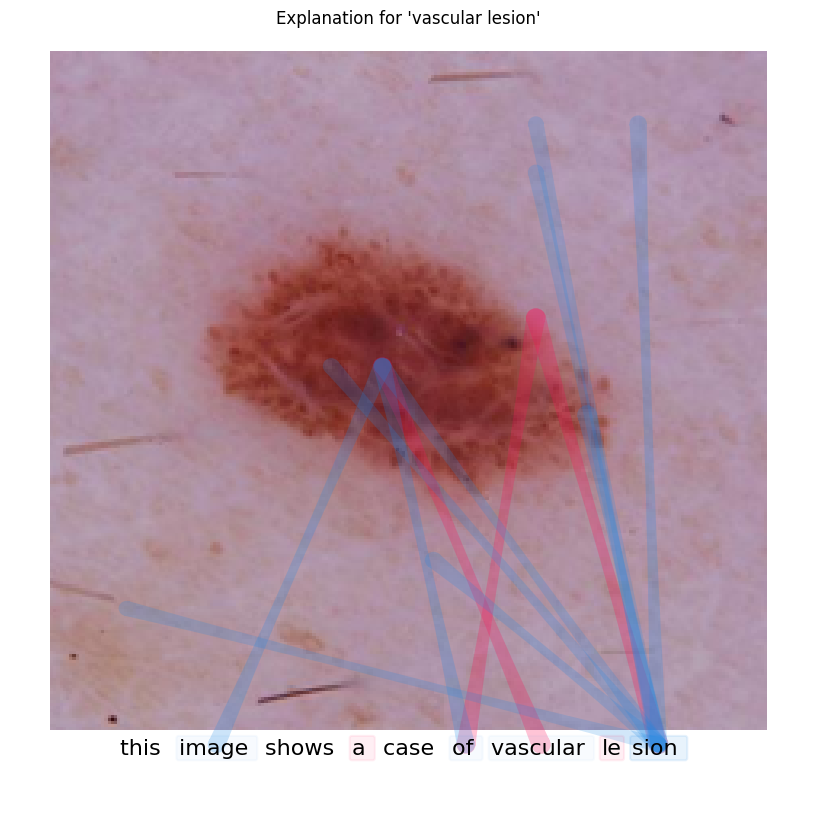


   ==> Generating Explanation for Class: 'dermatofibroma'


In [ ]:
import torch
import src.utils
import src.plot
import matplotlib.pyplot as plt
import open_clip
from transformers import AutoProcessor, AutoModel
import gc
from PIL import Image
from transformers import AutoTokenizer

CLASSES_HAM_7 = [
    "melanocytic nevus",
    "melanoma",
    "basal cell carcinoma",
    "benign keratosis",
    "actinic keratosis",
    "vascular lesion",
    "dermatofibroma"
]

data = [
    # {"filename": "ham_images/sample_0_melanocytic_Nevi.jpg"},
    # {"filename": "ham_images/sample_1_melanocytic_Nevi.jpg"},
    {"filename": "ham_images/sample_2_melanoma.jpg"}
    # {"filename": "ham_images/sample_3_melanoma.jpg"},
    # {"filename": "ham_images/sample_4_melanocytic_Nevi.jpg"}
]

template = lambda c: f'This image shows a case of {c}'

models_to_test = [
    {"name": "hf-hub:redlessone/DermLIP_ViT-B-16", "backend": "open_clip"}
    # {"name": "coca_ViT-B-32", "pretrained": "laion2b_s13b_b90k", "backend": "open_clip"}
    # {"name": "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224", "backend": "open_clip"}
]

results = {}

for model_info in models_to_test:
    model_name = model_info["name"]
    backend = model_info["backend"]
    print(f"\n{'='*60}\n[{model_name}] Loading Model...\n{'='*60}")

    # ==========================================
    # 1. Load Model dynamically based on backend
    # ==========================================
    if backend == "huggingface":
        model = AutoModel.from_pretrained(model_name).to('cuda').eval()
        processor = AutoProcessor.from_pretrained(model_name)
        tokenizer = processor 
        image_mean = processor.image_processor.image_mean
        image_std = processor.image_processor.image_std
    else: 
        pretrained = model_info.get("pretrained")
        if pretrained:
            model, _, processor = open_clip.create_model_and_transforms(model_name, pretrained=pretrained)
        else:
            model, _, processor = open_clip.create_model_and_transforms(model_name)
            
        model = model.to('cuda').eval()

        if "BiomedCLIP" in model_name:
            hf_tokenizer = AutoTokenizer.from_pretrained("microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224")
            
            class CustomHFTokenizer:
                def __init__(self, tk):
                    self.tk = tk
                
                def __call__(self, texts):
                    if isinstance(texts, str):
                        texts = [texts]
                    return self.tk(
                        texts,
                        return_tensors='pt',
                        max_length=256,
                        padding='max_length',
                        truncation=True
                    ).input_ids
                    
                def decode(self, token_ids):
                    return self.tk.decode(token_ids)
                    
            tokenizer = CustomHFTokenizer(hf_tokenizer)
        else:
            tokenizer = open_clip.get_tokenizer(model_name)
        
        image_mean = (0.48145466, 0.4578275, 0.40821073)
        image_std = (0.26862954, 0.26130258, 0.27577711)
        
        patch_size = 16
        if hasattr(model.visual, 'patch_size'):
            if isinstance(model.visual.patch_size, tuple):
                patch_size = model.visual.patch_size[0]
            else:
                patch_size = model.visual.patch_size

        print(f"     [Model Loaded] Image Mean={image_mean}, Image Std={image_std}, Patch Size={patch_size}")

    # Prepare zero-shot texts
    text_prompts = [template(c) for c in CLASSES_HAM_7]
    
    if backend == "huggingface":
        encoded_texts = tokenizer(text_prompts, return_tensors="pt", padding=True, truncation=True).to('cuda')
        with torch.no_grad(), torch.autocast("cuda"):
            text_features = model.get_text_features(**encoded_texts)
            text_features /= text_features.norm(dim=-1, keepdim=True)
    else:
        encoded_texts = tokenizer(text_prompts).to('cuda')
        with torch.no_grad(), torch.autocast("cuda"):
            text_features = model.encode_text(encoded_texts)
            text_features /= text_features.norm(dim=-1, keepdim=True)

    results[model_name] = []

    # ==========================================
    # 2. Iterate over samples
    # ==========================================
    for img_idx, item in enumerate(data): 
        img_path = item["filename"]
        print(f"\n{'*'*50}\n-> Processing Image {img_idx}: {img_path}\n{'*'*50}")
                
        try:
            input_image = Image.open(img_path).convert("RGB")
        except FileNotFoundError:
            print(f"     [!] Image not found at {img_path}. Skipping.")
            continue

        # ==========================================
        # 3. Compute Logits and Probabilities
        # ==========================================
        processed_img = processor(input_image).unsqueeze(0).to('cuda')
        with torch.no_grad(), torch.autocast("cuda"):
            if backend == "huggingface":
                image_features = model.get_image_features(processed_img)
            else:
                image_features = model.encode_image(processed_img)
                
            image_features /= image_features.norm(dim=-1, keepdim=True)
            
            # 100.0 is the typical default logit scale in CLIP models
            logits = 100.0 * image_features @ text_features.T
            text_probs = logits.softmax(dim=-1)
            
        print(f"\n--- Model Output for {img_path} ---")
        for c_idx, class_name in enumerate(CLASSES_HAM_7):
            print(f"  {class_name:<25}: Logit = {logits[0][c_idx].item():.4f}, Prob = {text_probs[0][c_idx].item():.4f}")
        print("-" * 35)

        # ==========================================
        # 4. Generate Explanations for ALL classes
        # ==========================================
        for c_idx, class_name in enumerate(CLASSES_HAM_7):
            input_text = template(class_name)
            print(f"\n   ==> Generating Explanation for Class: '{class_name}'")

            if backend == "huggingface":
                game = src.game_huggingface.VisionLanguageGame(
                    model=model,
                    processor=processor,
                    input_image=input_image,
                    input_text=input_text,
                    batch_size=32 
                )
            else:
                game = src.game_openclip.OpenCLIPGame(
                    model=model,
                    image_processor=processor,
                    text_tokenizer=tokenizer,
                    input_image=input_image,
                    input_text=input_text,
                    patch_size=patch_size,
                    batch_size=32 
                )

            approximator = src.fixlip.FIxLIP(
                n_players_text=game.n_players_text,
                n_players_image=game.n_players_image,
                max_order=2,
                p=0.5,
                random_state=42
            )
            
            budget = 2**8 if backend == "open_clip" else 2**8
            
            interaction_values = approximator.approximate_crossmodal(
                game=game,
                budget=budget
            )
            
            results[model_name].append({
                "filename": img_path,
                "target_class": class_name,
                "logit": logits[0][c_idx].item(),
                "probability": text_probs[0][c_idx].item(),
                "interaction_values": interaction_values
            })
            
            # ==========================================
            # 5. Extract Details & Visualize
            # ==========================================
            if backend == "huggingface":
                input_ids = game.inputs["input_ids"][0]
                if hasattr(tokenizer, "convert_ids_to_tokens"):
                    text_tokens = tokenizer.convert_ids_to_tokens(input_ids)
                else:
                    text_tokens = [tokenizer.decode([t.item()]) for t in input_ids]
            else:
                if hasattr(tokenizer, "decode"):
                    token_ids = tokenizer(input_text)[0]
                    text_tokens = [tokenizer.decode([t.item()]) for t in token_ids]
                else:
                    text_tokens = tokenizer(input_text)[0].numpy().tolist()
                    text_tokens = [str(t) for t in text_tokens]

            if len(text_tokens) > game.n_players_text:
                text_tokens = text_tokens[1:game.n_players_text+1]
            
            text_tokens = [tok.replace('</w>', '').replace('<|startoftext|>', '').replace('<|endoftext|>', '') for tok in text_tokens]
            
            if backend == "huggingface":
                input_image_processed = game.inputs['pixel_values'].squeeze(0)
            else:
                input_image_processed = game.inputs[0].squeeze(0)
                
            input_image_denormalized = src.utils.denormalize(
                input_image_processed, 
                image_mean, 
                image_std
            ).permute(1, 2, 0).numpy()
            
            src.plot.plot_image_and_text_together(
                img=input_image_denormalized,
                text=text_tokens,
                image_players=list(range(game.n_players_image)),
                iv=interaction_values,
                plot_interactions=True,
                top_k=13,
                normalize_jointly=True,
                figsize=(8, 8),
                fontsize=16,
                margin=0.3,
                color_text=True,
                plot_heatmap=True,
                show=True,
                max_value=float(interaction_values.values.max() * 4)
            )

            # Optional: Add title to easily identify class in plots
            plt.title(f"Explanation for '{class_name}'", pad=20)
            plt.tight_layout(pad=0.15)
            plt.show()
            plt.close('all')
            
            # Memory cleanup for inner class loop
            del game
            del approximator
            del interaction_values
                
            gc.collect()
            torch.cuda.empty_cache()

        # Cleanup for outer image loop
        del input_image
        del processed_img

print(f"\n[{model_name}] Finished!\n")

del model
del processor
if backend == "open_clip":
    del tokenizer
del text_features
del encoded_texts
torch.cuda.empty_cache()